## Test test

In [1]:
# setup imports
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.models import *
from src.paths import *
from ewatercycle.observation.grdc import get_grdc_data

from scipy.optimize import minimize
import numpy as np

import cma
import seaborn as sns
import pickle
from pathlib import Path


import warnings
warnings.filterwarnings("ignore", category=UserWarning)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:


results_folder = Path("results_6")
result_files = list(results_folder.glob("result_seed_*.pkl"))

loaded_results = []
for f in result_files:
    with open(f, "rb") as file:
        res = pickle.load(file)
        loaded_results.append(res)

# Example: print best objective per seed
for r in loaded_results:
    print(f"Seed {r['seed']}: best_f = {r['best_f']}, nfev = {r['nfev']}")


Seed 333444: best_f = 0.4951957042582742, nfev = 256
Seed 214025: best_f = 0.4491550369558619, nfev = 256
Seed 111222: best_f = 0.4491550369558619, nfev = 256
Seed 112233: best_f = 0.46832675782074723, nfev = 256
Seed 445566: best_f = 0.47159322984150503, nfev = 256
Seed 999000: best_f = 0.48364194508984454, nfev = 256
Seed 987654: best_f = 0.46937435741428424, nfev = 256
Seed 123456: best_f = 0.43735495340388153, nfev = 256
Seed 180988: best_f = 0.44299520085504174, nfev = 256
Seed 777888: best_f = 0.4474144491408154, nfev = 256
Seed 654321: best_f = 0.47400038520552085, nfev = 256
Seed 555666: best_f = 0.4539958273425721, nfev = 256


In [4]:
best_params_list = []

for run_idx, run in enumerate(loaded_results):
    seed = run['seed']
    history = run['history']
    
    # find the best evaluation by objective value
    best_idx = np.argmin(history['objective'])
    
    best_theta_phys = history['theta_phys'][best_idx]
    best_obj = history['objective'][best_idx]
    best_nse = history['nse'][best_idx]
    best_kge = history['kge'][best_idx]
    best_vol_err = history['vol_err'][best_idx]
    
    row = {
        'seed': seed,
        'best_eval': best_idx + 1,
        'objective': best_obj,
        'nse': best_nse,
        'kge': best_kge,
        'vol_err': best_vol_err
    }
    
    # add each parameter with its proper name
    for i, th in enumerate(best_theta_phys):
        row[parameter_names[i]] = th
    
    best_params_list.append(row)

# create DataFrame
best_params_df = pd.DataFrame(best_params_list)
best_params_df

,seed,best_eval,objective,nse,kge,vol_err,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
0,333444,218,0.495196,-0.058446,0.527609,0.089862,14.662507,0.349742,769.543757,1.468473,0.226732,7.944097,0.011176,0.005954,0.609250
1,214025,227,0.449155,0.042918,0.562157,0.076694,2.980130,0.927103,718.652707,3.480005,0.298566,6.605215,0.015031,0.009856,0.483329
2,111222,226,0.449155,0.042918,0.562157,0.076694,3.868356,0.525291,565.750134,2.369541,0.283991,7.683474,0.010133,0.008807,0.765527
3,112233,239,0.468327,0.001259,0.531651,0.070500,21.174175,0.409072,792.946455,1.601482,0.273813,6.902742,0.010204,0.006975,0.690372
4,445566,233,0.471593,0.022406,0.528528,0.092183,21.520574,0.401190,777.290278,1.636273,0.291493,11.992307,0.010000,0.009133,0.788288
5,999000,178,0.483642,-0.099870,0.514915,0.020389,10.158957,0.664810,705.893681,2.571798,0.297857,4.932924,0.012296,0.007216,0.785039
6,987654,151,0.469374,-0.056878,0.526743,0.025835,19.118061,0.587835,591.411244,2.242160,0.273709,4.606868,0.010042,0.004775,0.796755
7,123456,240,0.437355,0.007276,0.547050,0.009131,0.222612,0.473759,721.898890,1.939276,0.283583,7.902570,0.010001,0.005879,0.790641
8,180988,249,0.442995,0.025473,0.560219,0.046757,8.931827,0.510922,603.158537,2.144487,0.297854,4.473814,0.010794,0.008425,0.773455
9,777888,200,0.447414,-0.010107,0.548878,0.022615,2.553228,0.450802,552.676791,1.975581,0.257980,5.146584,0.010313,0.008761,0.751603


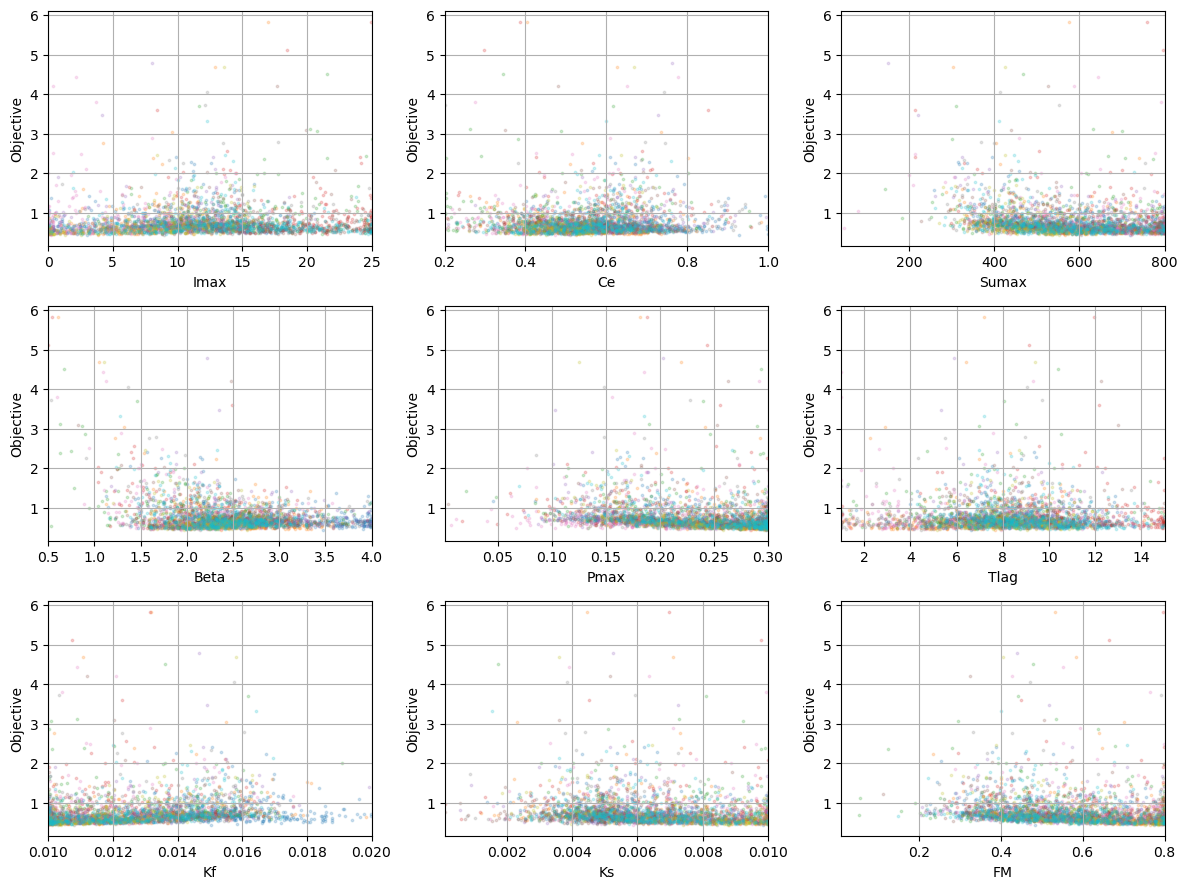

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Suppose you have multiple seeds in `results`:
dfs = []
for seed_idx, res_seed in enumerate(loaded_results):
    hist = res_seed['history']
    df = pd.DataFrame(hist)
    df['seed'] = seed_idx  # add a seed column
    dfs.append(df)

history_df = pd.concat(dfs, ignore_index=True)

n_params = len(p_min)  # 9
seeds = history_df['seed'].unique()  # get all unique seeds
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))  # assign colors

n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  # flatten for easy indexing

for i in range(n_params):
    ax = axes[i]
    
    for seed, color in zip(seeds, colors):
        theta_array = np.stack(history_df.loc[history_df['seed']==seed, 'theta_phys'].values)
        obj_array = history_df.loc[history_df['seed']==seed, 'objective'].values
        ax.scatter(theta_array[:, i], obj_array, label=f"Seed {seed}", color=color, alpha=0.2, s=3)
        ax.set_xlabel(parameter_names[i])
    
    ax.set_ylabel("Objective")
    #ax.set_title()
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

# remove empty axes
for j in range(n_params, len(axes)):
    fig.delaxes(axes[j])


#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


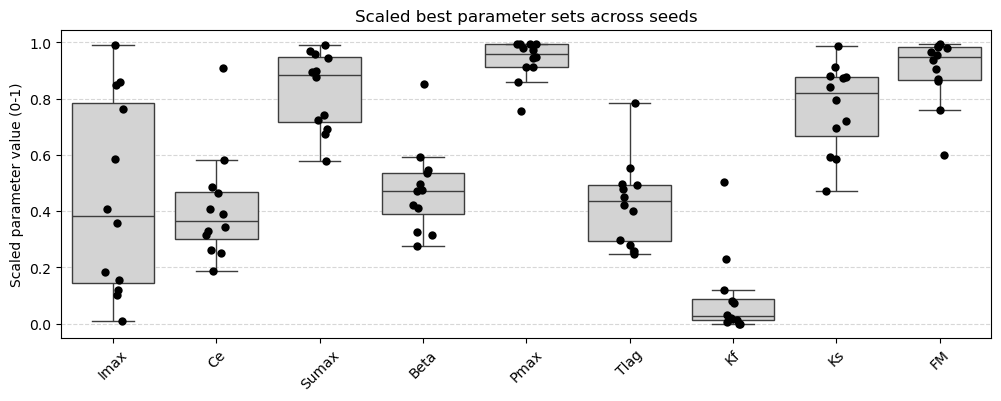

In [6]:
# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Scale the best parameters
scaled_params_df = pd.DataFrame(scale(best_params_df[param_cols].to_numpy()), 
                                columns=param_cols)


plt.figure(figsize=(12,4))
# sns.boxplot(data=scaled_params_df, color = 'lightgray')
# sns.stripplot(data=scaled_params_df, color='black', jitter=False, size=8)
sns.boxplot(data=scaled_params_df, color='lightgray', fliersize=0)  # light gray boxes, hide default outliers
sns.stripplot(data=scaled_params_df, color='black', jitter=True, size=6, marker='o')  # black dots

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title("Scaled best parameter sets across seeds")
# add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [7]:
rows = []

for run_idx, run in enumerate(loaded_results):
    seed = run['seed']
    history = run['history']
    
    n_eval = len(history['objective'])
    
    for i in range(n_eval):
        row = {
            'seed': seed,
            'eval': i + 1,
            'objective': history['objective'][i],
            'nse': history['nse'][i],
            'kge': history['kge'][i],
            'vol_err': history['vol_err'][i],
        }
        
        # parameters
        for j, th in enumerate(history['theta_phys'][i]):
            row[parameter_names[j]] = th
        
        rows.append(row)

all_results_df = pd.DataFrame(rows)
best_row = all_results_df.loc[all_results_df['objective'].idxmin()]

print(best_row)

seed         123456.000000
eval            240.000000
objective         0.437355
nse               0.007276
kge               0.547050
vol_err           0.009131
Imax              0.222612
Ce                0.473759
Sumax           721.898890
Beta              1.939276
Pmax              0.283583
Tlag              7.902570
Kf                0.010001
Ks                0.005879
FM                0.790641
Name: 2031, dtype: float64


In [8]:
q = 0.02  # best 5%
threshold = all_results_df['objective'].quantile(q)

best_5pct_df = all_results_df[
    all_results_df['objective'] <= threshold
].sort_values('objective')


In [9]:
len(best_5pct_df), len(all_results_df)


(62, 3072)

In [10]:
best_5pct_df['seed'].value_counts()


seed
111222    16
777888    14
555666     9
123456     8
180988     5
987654     4
214025     2
654321     2
112233     1
445566     1
Name: count, dtype: int64

In [11]:
# 1. Make a copy of describe
desc_fixed = best_params_df[parameter_names].describe()

# 2. Convert count to int
desc_fixed.loc['count'] = desc_fixed.loc['count'].apply(int)

# 3. Round other stats
desc_fixed.loc[desc_fixed.index != 'count'] = desc_fixed.loc[desc_fixed.index != 'count'].round(3)

# 4. Set index name
desc_fixed.index.name = 'Statistic'

# 5. Rename the problematic row labels (the index)
desc_fixed = desc_fixed.rename(index={
    '25%': 'Q25',
    '50%': 'Median',
    '75%': 'Q75'
})

# 6. Export to LaTeX
latex_table = desc_fixed.to_latex(
    index=True,
    float_format="%.3f",
    caption="Summary statistics of calibrated parameters",
    label="tab:param_summary",
    escape=False  # safe since we removed problematic % signs
)

# 7. Write to file
with open("parameter_summary.tex", "w") as f:
    f.write(latex_table)

print("LaTeX table saved as 'parameter_summary.tex'")


LaTeX table saved as 'parameter_summary.tex'


In [12]:
print(desc_fixed.index)

Index(['count', 'mean', 'std', 'min', 'Q25', 'Median', 'Q75', 'max'], dtype='object', name='Statistic')


In [13]:
best_5pct_df[parameter_names].describe()


,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,6.460909,0.529382,610.102558,2.323819,0.281804,6.974545,0.010846,0.007971,0.728417
std,6.248699,0.122471,95.452018,0.493009,0.022134,2.774807,0.001135,0.001574,0.074286
min,0.006497,0.301275,387.063519,1.601482,0.205540,1.215745,0.010000,0.003970,0.471946
25%,1.515321,0.451786,538.123637,1.996865,0.274586,4.716593,0.010133,0.007107,0.697294
50%,5.360329,0.513658,592.389265,2.246253,0.290312,6.723286,0.010384,0.008262,0.744728
75%,8.650213,0.577274,679.924283,2.570052,0.297652,9.357187,0.011083,0.009023,0.786576
max,24.956074,0.999592,794.965445,3.904465,0.299981,12.897955,0.015850,0.009994,0.799963


In [14]:
# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Extract parameters as array
theta = best_5pct_df[param_cols].to_numpy()

# Apply your scaling
scaled_theta = scale(theta)

# Back to DataFrame
scaled_params_df = pd.DataFrame(
    scaled_theta,
    columns=param_cols
)


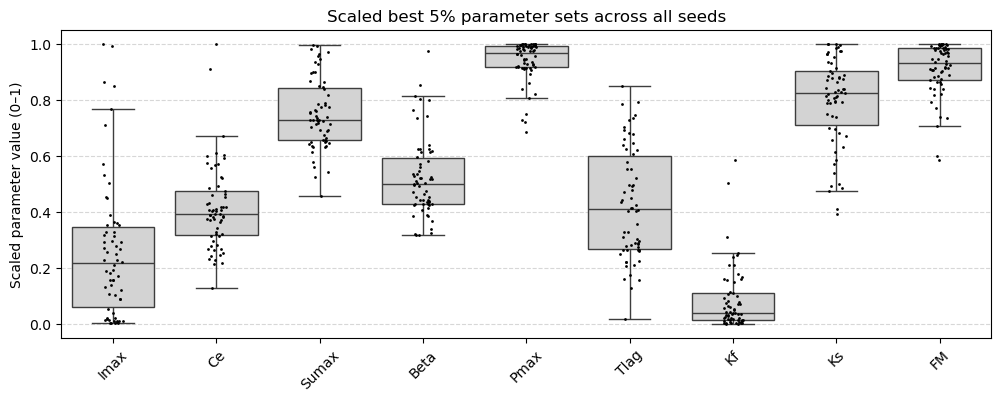

In [15]:
plt.figure(figsize=(12,4))

sns.boxplot(
    data=scaled_params_df,
    color='lightgray',
    fliersize=0
)

sns.stripplot(
    data=scaled_params_df,
    color='black',
    jitter=True,
    size=2,
    marker='o'
)

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best 5% parameter sets across all seeds")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


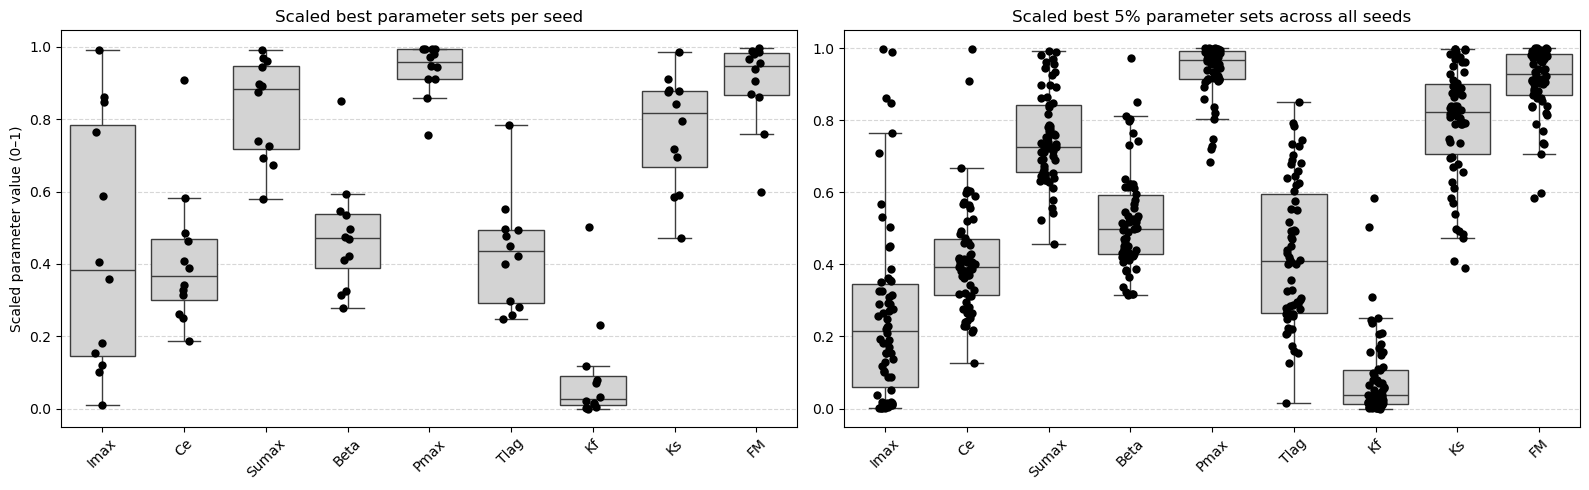

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()),
    columns=param_cols
)

scaled_best_5pct = pd.DataFrame(
    scale(best_5pct_df[param_cols].to_numpy()),
    columns=param_cols
)

# Create figure with 2 subplots
plt.figure(figsize=(16,5))

# Left: best per seed
plt.subplot(1,2,1)
sns.boxplot(data=scaled_best_per_seed, color='lightgray', fliersize=0)
sns.stripplot(data=scaled_best_per_seed, color='black', jitter=True, size=6, marker='o')
plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best parameter sets per seed")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Right: top 5%
plt.subplot(1,2,2)
sns.boxplot(data=scaled_best_5pct, color='lightgray', fliersize=0)
sns.stripplot(data=scaled_best_5pct, color='black', jitter=True, size=6, marker='o')
plt.xticks(rotation=45)
plt.ylabel("")
plt.title("Scaled best 5% parameter sets across all seeds")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()),
    columns=param_cols
)
scaled_best_5pct = pd.DataFrame(
    scale(best_5pct_df[param_cols].to_numpy()),
    columns=param_cols
)

# Add a column to identify the group
scaled_best_per_seed['group'] = 'best per seed'
scaled_best_5pct['group'] = f"top {int(100*q)}%"

# Combine both datasets
combined_df = pd.concat([scaled_best_per_seed, scaled_best_5pct], ignore_index=True)

# Melt to long format for seaborn
long_df = combined_df.melt(id_vars='group', value_vars=param_cols, 
                           var_name='parameter', value_name='scaled_value')




In [18]:
long_df['group'].unique()

array(['best per seed', 'top 2%'], dtype=object)

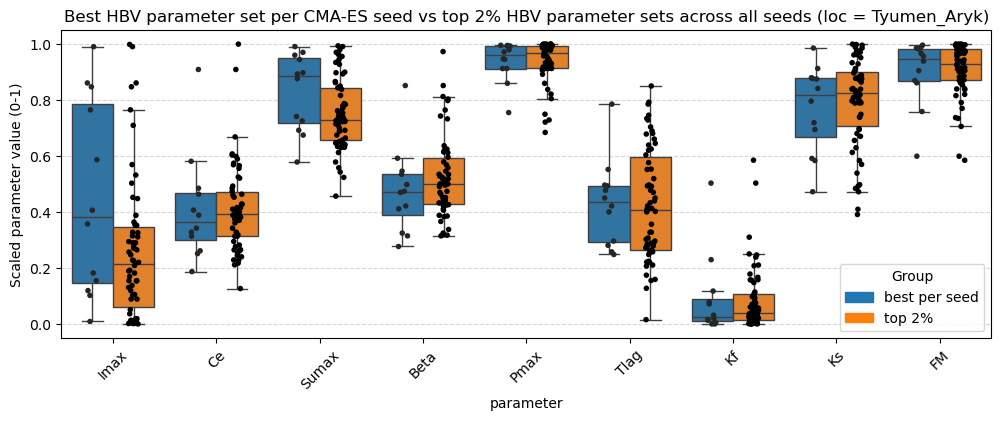

In [19]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))

# palette = {
#     'best per seed': 'darkgray',
#     f"top {int(100*q)}%": 'dimgray'
# }

palette = {
    'best per seed': '#1f77b4',        # blue
    f"top {int(100*q)}%": '#ff7f0e'   # orange
}


sns.boxplot(
    data=long_df,
    x='parameter',
    y='scaled_value',
    hue='group',
    palette=palette,
    fliersize=0
)

sns.stripplot(
    data=long_df,
    x='parameter',
    y='scaled_value',
    hue='group',
    dodge=True,
    jitter=True,
    size=4,
    marker='o',
    alpha=1,
    palette="dark:black",
    legend=False  # avoid duplicate legend entries
)

# 3️⃣ Custom legend from boxplot colors only
handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
plt.legend(handles=handles, title='Group')

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title(f"Best HBV parameter set per CMA-ES seed vs top {int(100*q)}% HBV parameter sets across all seeds (loc = Tyumen_Aryk)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [20]:
loaded_results

[{'seed': 333444,
  'best_f': 0.4951957042582742,
  'best_x': array([0.58650029, 0.18717735, 0.959926  , 0.27670657, 0.75495516,
         0.49600696, 0.11764974, 0.59134975, 0.75854449]),
  'nfev': 256,
  'sigma_final': 0.12668686497116083,
  'history': {'theta_norm': [array([0.26569307, 0.64781987, 0.51722449, 0.7907757 , 0.47674115,
           0.46815452, 0.47717571, 0.46043179, 0.53732556]),
    array([0.41355379, 0.47452287, 0.36704431, 0.44185837, 0.81943383,
           0.39506289, 0.46436301, 0.64648909, 0.50211324]),
    array([0.45986233, 0.47900341, 0.47266459, 0.4803727 , 0.55048792,
           0.54611975, 0.56485752, 0.57877874, 0.54249745]),
    array([0.31826651, 0.5661648 , 0.63500359, 0.62450202, 0.66235349,
           0.55669455, 0.3552225 , 0.52329394, 0.48400085]),
    array([0.46798197, 0.33101739, 0.54066428, 0.74345726, 0.35009728,
           0.47753976, 0.5266993 , 0.47343277, 0.52055659]),
    array([0.4649493 , 0.30633693, 0.43854489, 0.41501507, 0.69691423,
   

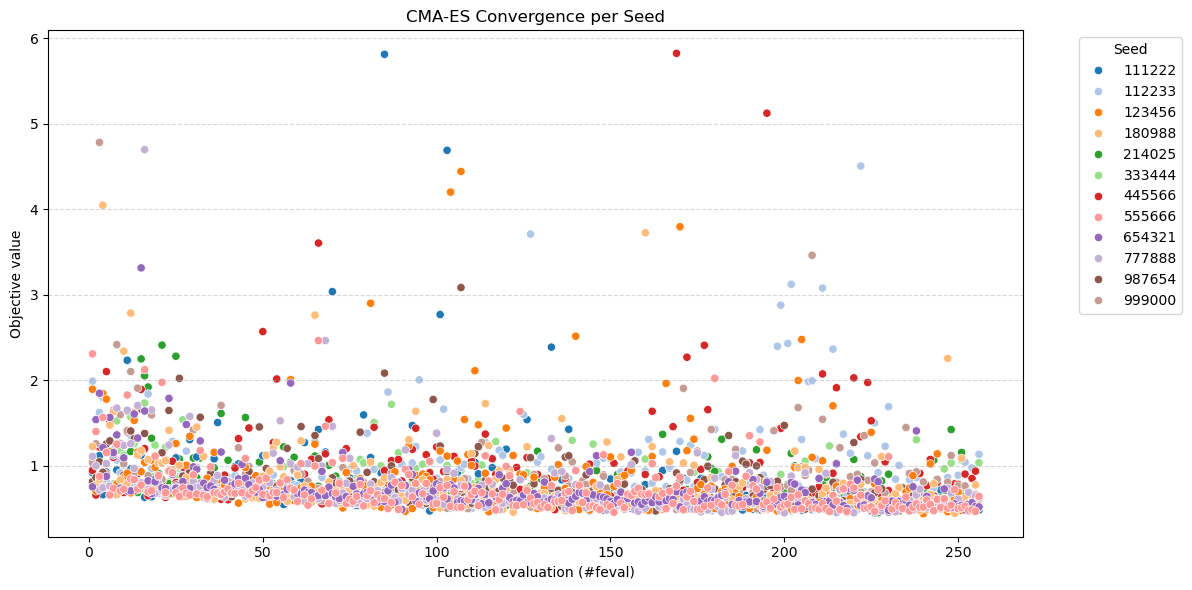

In [21]:
plot_data = []

for run in loaded_results:
    seed = run['seed']
    history = run['history']
    
    fevals = list(range(1, len(history['objective']) + 1))  # #feval
    objectives = history['objective']
    
    for f, obj in zip(fevals, objectives):
        plot_data.append({'seed': seed, 'feval': f, 'objective': obj})

df_plot = pd.DataFrame(plot_data)

# Plot
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_plot,
    x='feval',
    y='objective',
    hue='seed',
    marker='o',
    palette='tab20'  # can use any palette
)

plt.xlabel("Function evaluation (#feval)")
plt.ylabel("Objective value")
plt.title("CMA-ES Convergence per Seed")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Seed', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

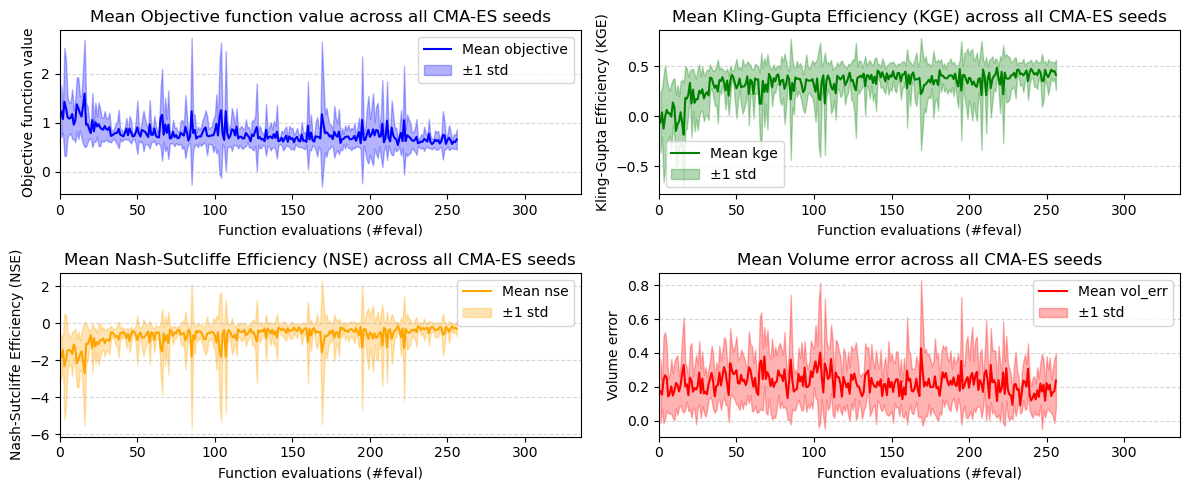

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics = ['objective', 'kge', 'nse', 'vol_err']

# Mapping from metric key to long/descriptive name
metric_names = {
    'objective': 'Objective function value',
    'kge': 'Kling-Gupta Efficiency (KGE)',
    'nse': 'Nash-Sutcliffe Efficiency (NSE)',
    'vol_err': 'Volume error'
}

# Build DataFrame of all seeds and metrics
plot_data = []

for run in loaded_results:
    seed = run['seed']
    history = run['history']
    fevals = np.arange(1, len(history['objective']) + 1)
    
    for f in fevals:
        row = {'seed': seed, 'feval': f}
        for m in metrics:
            row[m] = history[m][f-1]  # f-1 because fevals start at 1
        plot_data.append(row)

df_plot = pd.DataFrame(plot_data)

# Plot mean ± std for each metric
plt.figure(figsize=(12,5))

colors = {'objective':'blue', 'kge':'green', 'nse':'orange', 'vol_err':'red'}

for i, metric in enumerate(metrics, 1):
    plt.subplot(2,2,i)
    
    df_summary = df_plot.groupby('feval')[metric].agg(['mean','std']).reset_index()
    
    plt.plot(df_summary['feval'], df_summary['mean'], color=colors[metric], label=f'Mean {metric}')
    plt.fill_between(
        df_summary['feval'],
        df_summary['mean'] - df_summary['std'],
        df_summary['mean'] + df_summary['std'],
        color=colors[metric],
        alpha=0.3,
        label='±1 std'
    )
    
    plt.xlabel("Function evaluations (#feval)")
    plt.ylabel(metric_names[metric])
    plt.title(f"Mean {metric_names[metric]} across all CMA-ES seeds")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.xlim(0,336)

plt.tight_layout()
plt.show()


